# Part 2: Dynestyx — NumPyro with better support for dynamical systems
We introduce **dynestyx** as an extension of NumPyro for **dynamical systems**, with a clear separation between *what* the model is and *how* we simulate or score it.

## 2.1 Separation of concerns

**Dynestyx** extends NumPyro by giving you a standard way to work with dynamical systems. The key idea is **separation of concerns**:

- **What** the model is: parameters $\theta$, initial condition $p(x_0)$, state evolution (discrete or continuous time), observation model $p(y_t \mid x_t, \ldots)$. This is the `DynamicalModel`—you write it once as a generative model in code.
- **How** we simulate: *simulators* (e.g. `DiscreteTimeSimulator`, `SDESimulator`) unroll the dynamics step-by-step and generate state/observation trajectories. They interpret `dsx.sample("name", dynamics)` as "run the model forward in time."
- **How** we do inference: we can use either *simulators* (which sample latent states $x_{0:T}$ explicitly) or *filters* (which marginalize over them and compute $p(y_{1:T} \mid \theta)$). On top of that, we run standard NumPyro inference—**NUTS**, **SVI**, or others—to infer parameters (and optionally latent states when using a simulator).

You write the model once; then you choose how to interpret it (simulator vs. filter) and which inference algorithm to use.

## 2.2 A first Dynestyx model

For pedagogical purposes, we begin with a classic discrete-time linear-Gaussian system with controls. 

$$
\begin{aligned}
x_{t+1} &= Ax_t + Bu_t + \epsilon_t \\
y_t &= Cx_t + \eta_t
\end{aligned}
$$
with
$$
\begin{aligned}
x_0 &\sim \mathcal{N}(m_0, \ C_0) \\
\epsilon_t &\sim \mathcal{N}(0, \ \Sigma)  \\
\eta_t &\sim \mathcal{N}(0, \ \Gamma) 
\end{aligned}
$$

Written differently, we have:
$$
\begin{aligned}
\text{Initial Condition:} \quad x_0 &\sim \mathcal{N}(m_0, \ C_0) \\
\text{State-transition:} \quad x_{t+1} &\sim \mathcal{N}(Ax_t + Bu_t, \ \Sigma) \\
\text{Observation model:} \quad y_{t} &\sim \mathcal{N}(Cx_t, \ \Gamma) \\
\end{aligned}
$$

Furthermore, say we have prior belief about a subset of parameters in the model. Concretely, we will assume

$$
\begin{aligned}
A &= \begin{bmatrix} 0 & 0.3 \\ \rho & -0.2 \end{bmatrix} \\
B &= \begin{bmatrix} 1 \\ 0 \end{bmatrix} \\
C &= \begin{bmatrix} 1 & 0 \end{bmatrix} \\
\Sigma &= 0.1^2 I \\
\Gamma &= 0.1^2 I \\
m_0 &= 0\\
C_0 &= I
\end{aligned}
$$

and place a prior over the single unknown, $\rho$, in the system:

$$ \rho \sim \mathcal{U}([-0.9, 0.9]).$$

This induces a generative model.


At the highest level, the idea is to create a NumPyro model that samples from this dynamical system. To do this, we use the `DynamicalModel` class in dynestyx, paired with the `dsx.sample` statement. 

In [11]:
import numpyro
import numpyro.distributions as dist

import dynestyx as dsx
from dynestyx import DynamicalModel


def fake_lti_model(obs_times=None, obs_values=None):
    # sample the unknown parameter
    rho = numpyro.sample("rho", dist.Uniform(-0.9, 0.9))
    # create the dynamical model depending on the parameter
    rho_dynamics = DynamicalModel(..., rho, ...)  # not real syntax
    # sample from the dynamical model
    dsx.sample("f", rho_dynamics, obs_times=obs_times, obs_values=obs_values)

At this level, you can think of writing `dsx.sample(...)` as rather abstract---at this point, we don't worry about HOW to sample the system. 

Why? Dynestyx allows us to have different "interpretations" of the `dsx.sample` statement, depending on the task at hand. To give a few examples of how we may interpret the dynamical system later, we may:
- Use algorithmic strategies (e.g., filtering or smoothing) to efficiently condition `lti_model` on available data.
- Specify key parts of *how* we simulate, which is particularly important when we use differential equations later on.
- Explore various approximations of the dynamical system (e.g., Gaussian states, linear observations, or discretizations of a differential equation), *without* modifying the underlying model.
- Freely experiment with these differing strategies as part of the Bayesian workflow discussed in the previous tutorial.

Let's dive in a bit more how to build a `DynamicalModel`.

The `DynamicalModel` class can be instantiated with three main ingredients:
- `initial_condition`: can be any NumPyro distribution
- `state_evolution`: can be one of two classes
    - `DiscreteTimeStateEvolution`:
        - A callable $(x, u, t_\text{now}, t_\text{next}) \mapsto \ $ `numpyro.distributions` object (which can include things like categorical distributions)
    - `ContinuousTimeStateEvolution`: has fields
        - `drift`: A callable $(x, u, t) \mapsto \ \mathbb{R}^{d_x}$
        - `diffusion_coefficient`: A callable $(x, u, t) \mapsto \ \mathbb{R}^{d_x \times d_x}$
        - `diffusion_covariance`: A callable $(x, u, t) \mapsto \ \mathbb{R}^{d_x \times d_x}$
- `observation_model`: A callable $(x, u, t) \mapsto \ $ `numpyro.distributions` object

It also requires specification of the key dimensions in the problem:
- `state_dim`: $\text{dim}(x_t)$
- `observation_dim`: $\text{dim}(y_t)$
- `control_dim`: $\text{dim}(u_t)$


In [12]:
import jax.numpy as jnp

from dynestyx.models import DynamicalModel  # noqa: F811

# for convenience, we can define "fixed" things in the model outside of it.
# this is not required, but it helps keep the model clean.
state_dim = 2
observation_dim = 1
control_dim = 1

# Create the known matrices B, C
B = jnp.eye(state_dim, control_dim)
C = jnp.eye(observation_dim, state_dim)

# create the initial condition as a distribution
initial_condition = dist.MultivariateNormal(jnp.zeros(state_dim), jnp.eye(state_dim))

# create the observation model as a callable mapping to a distribution
observation_model = lambda x, u, t: dist.MultivariateNormal(
    C @ x, 0.1**2 * jnp.eye(observation_dim)
)


def lti_model(rho=None, obs_times=None, obs_values=None, ctrl_times=None, ctrl_values=None, predict_times=None):
    # sample the unknown parameter
    rho = numpyro.sample("rho", dist.Uniform(-0.5, 0.5), obs=rho)
    A = jnp.array([[0, 0.3], [rho, -0.2]])

    # create the state evolution as a callable mapping to a distribution
    # Crucially, this depends on A, which depends on rho, which is unknown.
    # Thus, the state evolution MUST be defined within `lti_model`, not outside.
    state_evolution = lambda x, u, t_now, t_next: dist.MultivariateNormal(
        A @ x + B @ u, 0.1**2 * jnp.eye(state_dim)
    )

    # create the dynamical model
    dynamics = DynamicalModel(
        control_dim=control_dim,
        initial_condition=initial_condition,
        state_evolution=state_evolution,
        observation_model=observation_model,
    )

    # sample from the dynamical model
    return dsx.sample("f", dynamics, obs_times=obs_times, obs_values=obs_values, ctrl_times=ctrl_times, ctrl_values=ctrl_values, predict_times=predict_times)

## 2.3 Making "data": observation and control trajectories

Dynestyx models take trajectory data as keyword arguments: `obs_times`, `obs_values`, `predict_times`, `ctrl_times`, and `ctrl_values`.

- **`obs_times`** and **`obs_values`**: Always provided together. They represent **observed data** — times $\{t_k\}_{k=0}^K$ and values $\{y_k\}_{k=0}^K$ at which we have measurements. When provided, the model is conditioned on these observations.
- **`predict_times`**: Times at which to predict or simulate — defines the time grid for the solver/simulator. Use this alone for pure forward simulation (no data); use with `obs_times` when predicting at additional times beyond the observed data.
- **`ctrl_times`** and **`ctrl_values`**: Control inputs; provided together; must align with the union of `obs_times` and `predict_times`.

Our first step will be to simulate data from the generative model. To do this, we define the times at which we should simulate (`predict_times`) and a synthetic control sequence.

In [13]:
import jax.random as jr

# For simulation: predict_times defines the time grid (no observed data yet)
predict_times = jnp.arange(0.0, 100.0, 1.0)  # T=100 steps
ctrl_times = predict_times  # same times for controls

# create a synthetic control sequence as i.i.d. Gaussians
# (in practice, this would be an array of control inputs that we have observed)
ctrl_values = jr.normal(jr.PRNGKey(0), (len(ctrl_times), control_dim))

# For an autonomous system, we would simply omit ctrl_times and ctrl_values.

## 2.4 Interpreting the model with a Simulator

To generate data, we interpret `dsx.sample("f", dynamics, predict_times=..., ctrl_times=..., ctrl_values=...)` using a **Simulator**. The `DiscreteTimeSimulator` unrolls the model step-by-step at the given times. For pure simulation (no observed data), we pass `predict_times`, `ctrl_times`, and `ctrl_values` directly to the model.

## How does this interpretation manifest under-the-hood?

The `DiscreteTimeSimulator` simply "unrolls" the dynamical system into a normal NumPyro probabilistic program. This internally does something like the following, but more efficiently using `jax.scan`:

```python
def simulated_program(...):
    # Probabilistic program before dsx.sample
    # ...
    # dsx.sample(...):
    
    T = len(times)  # times = predict_times for simulation, or union of obs_times and predict_times

    x_prev = numpyro.sample("x_0", initial_condition)
    y_0 = numpyro.sample("y_0", dynamics.observation_model(x=x_prev, t=times[0]))

    for t_idx in range(T-1):
        t_now = times[t_idx]
        t_next = times[t_idx+1]

        x_t = numpyro.sample(f"x_{t_idx+1}", 
                            dynamics.state_evolution(x=x_prev, 
                                                    t=t_now, 
                                                    t_next=t_next))
        y_t = numpyro.sample(f"y_{t_idx+1}", 
                            dynamics.observation_model(x=x_t, t=t_next), 
                            obs=obs_values[t_idx+1])
```

## 2.5 Predictive (for generating synthetic data)

We use NumPyro's `Predictive` to generate samples from the model. With `DiscreteTimeSimulator` in place, we pass `predict_times`, `ctrl_times`, and `ctrl_values` to produce one trajectory—states and observations—at the given times.

Here, we generate a single synthetic dataset with $\rho = 0.3$


In [14]:
from numpyro.infer import Predictive
from dynestyx import DiscreteTimeSimulator

rho_true = 0.3
with DiscreteTimeSimulator():
    predictive = Predictive(
        lti_model,
        params={"rho": jnp.array(rho_true)},
        num_samples=1,
        exclude_deterministic=False,
    )

    pred = predictive(rng_key=jr.PRNGKey(0), predict_times=predict_times, ctrl_times=ctrl_times, ctrl_values=ctrl_values)

**Shape convention note:** simulator outputs now always include a leading `n_simulations` axis, even when `n_simulations=1`. Under `Predictive`, there is also a leading `num_samples` axis. In examples below we use a helper that removes only leading singleton axes for plotting/conditioning.

Now extract and plot the generated data:

dict_keys(['f_observations', 'f_states', 'f_times', 'f_x_0', 'f_x_Traced<int32[]>with<DynamicJaxprTrace>', 'f_y_0', 'f_y_Traced<int32[]>with<DynamicJaxprTrace>', 'rho'])
shapes: (1, 1, 100) (1, 1, 100, 2) (1, 1, 100, 1)


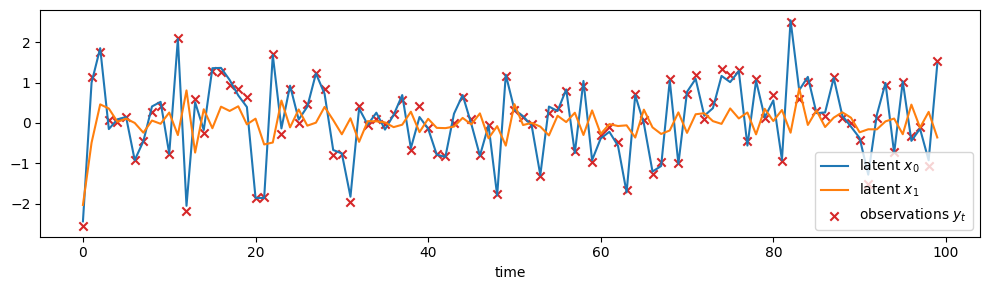

In [15]:
# Extract observations and states for plotting (and for inference below)
# obs_times and obs_values are the data we'll condition on for inference.
print(pred.keys())
print(
    "shapes:",
    pred["f_times"].shape,
    pred["f_states"].shape,
    pred["f_observations"].shape,
)

# Expected with num_samples=1 and n_sim=1:
# f_times: (1, 1, T), f_states: (1, 1, T, state_dim), f_observations: (1, 1, T, obs_dim)
obs_times = pred["f_times"][0, 0, :]
states = pred["f_states"][0, 0, :, :]
obs_values = pred["f_observations"][0, 0, :, 0]

# Plot
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(obs_times, states[:, 0], label="latent $x_0$", color="C0")
ax.plot(obs_times, states[:, 1], label="latent $x_1$", color="C1")
ax.scatter(obs_times, obs_values, label="observations $y_t$", color="C3", marker="x")
ax.legend()
ax.set_xlabel("time")
plt.tight_layout()
plt.show()

## 2.6 Inference: conditioning on data

To do inference given data, we pass the observed values along with the times and controls to the model:

In [16]:
# obs_times, obs_values, ctrl_times, ctrl_values are already defined above

In dynestyx, we perform inference using the same tools as NumPyro, just with the correct interpretation of `dsx.sample(...)`. This requires two things:

1. Data: **`obs_times`, `obs_values`, `ctrl_times`, `ctrl_values`** are passed to the model to specify what data to condition on. When `obs_values` is provided, those sites become observed (not sampled).
2. An Inference Method: for now, we use **`with DiscreteTimeSimulator():`**, which tells us HOW to condition the model on the data (same as for simulation).



The result is a standard NumPyro model: we can run **NUTS**, **SVI**, or any other NumPyro inference on it.

In [17]:
from numpyro.infer import MCMC, NUTS

with DiscreteTimeSimulator():
    nuts_kernel = NUTS(lti_model)
    mcmc = MCMC(nuts_kernel, num_warmup=101, num_samples=101)
    mcmc.run(jr.PRNGKey(1), obs_times=obs_times, obs_values=obs_values, ctrl_times=ctrl_times, ctrl_values=ctrl_values)

posterior_sv = mcmc.get_samples()
print("Posterior rho mean:", float(jnp.mean(posterior_sv["rho"])))
print("True rho:", rho_true)

# What did we infer? The Simulator unrolled the model, so we explicitly sampled latent states:
print(posterior_sv.keys())

# Print the shapes of each of the keys in the posterior samples
for key, value in posterior_sv.items():
    print(f"{key}: {value.shape}")

sample: 100%|██████████| 202/202 [00:00<00:00, 246.21it/s, 31 steps of size 1.49e-01. acc. prob=0.93]

Posterior rho mean: 0.3294023275375366
True rho: 0.3
dict_keys(['f_observations', 'f_states', 'f_times', 'f_x_0', 'f_x_Traced<int32[]>with<DynamicJaxprTrace>', 'rho'])
f_observations: (101, 1, 100)
f_states: (101, 1, 100, 2)
f_times: (101, 1, 100)
f_x_0: (101, 1, 2)
f_x_Traced<int32[]>with<DynamicJaxprTrace>: (101, 99, 1, 2)
rho: (101,)


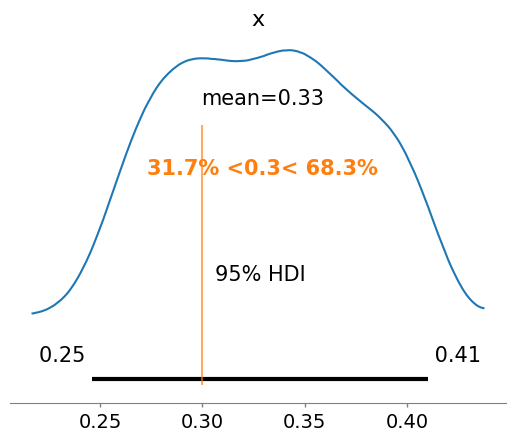

In [18]:
# use ArviZ to plot the posterior distribution for rho
import arviz as az

az.plot_posterior(posterior_sv["rho"], hdi_prob=0.95, ref_val=rho_true)
plt.show()

### What the Simulator did: unrolling

Using the **Simulator** effectively *unrolled* the model: instead of a single `dsx.sample("f", dynamics)` call, the dynamics were expanded into explicit sample sites `states` ($x_0, x_1, \ldots, x_T$) and `observations` ($y_0, y_1, \ldots, y_T$). Pedagogically, the Simulator does something like:

```python
# Conceptual unrolling (what the Simulator does internally):
x_0 = numpyro.sample("x_0", initial_condition)
y_0 = numpyro.sample("y_0", observation_model(x_0, u_0, t_0))
x_1 = numpyro.sample("x_1", state_evolution(x_0, u_0, t_0, t_1))
y_1 = numpyro.sample("y_1", observation_model(x_1, u_1, t_1))
# ... and so on for each time step
```

So MCMC was inferring **both** the parameter $\rho$ and the full latent state trajectory $x_{0:T}$ explicitly. The printed sample keys include `rho` and `states`, ….

For simple Gaussian problems like this one, unrolling can be an excellent strategy that NUTS can handle quite well! We obtain a `smoothing` distribution of the resulting data, without running a typical smoothing algorithm -- we will do this in later tutorials, and see its advantages and drawbacks depending on the type of data at hand. For now, let us compare the state recovery of the unrolled MCMC inference compared to the true states generated in the original model simulation.

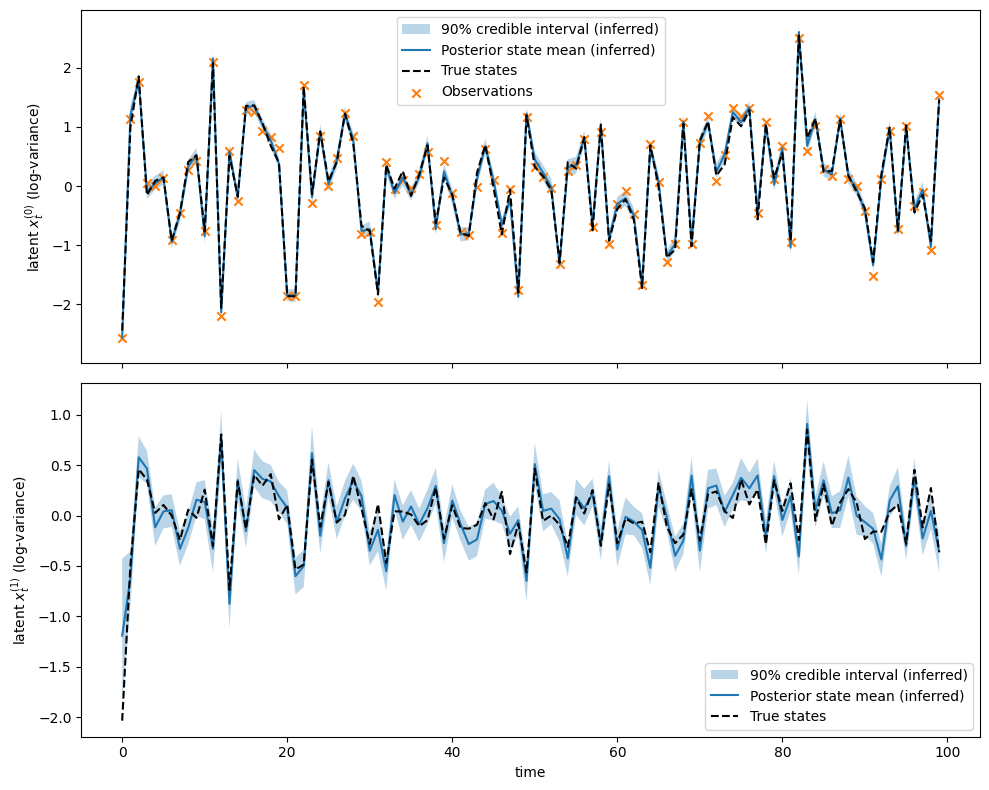

In [19]:
# Plot inferred states vs true states: posterior distribution over the latent trajectory,
# with a subplot for each latent variable/state dimension
inferred_states = posterior_sv["f_states"]  # (n_samples, n_sims, T+1, state_dim)
n_samples, _, T1, state_dim = inferred_states.shape

true_states = jnp.asarray(states)


posterior_mean = inferred_states.mean(axis=(0,1))  # (T+1, state_dim)
q05 = jnp.percentile(inferred_states, 5, axis=(0,1))  # (T+1, state_dim)
q95 = jnp.percentile(inferred_states, 95, axis=(0,1))  # (T+1, state_dim)

fig, axes = plt.subplots(state_dim, 1, figsize=(10, 4 * state_dim), sharex=True)
if state_dim == 1:
    axes = [axes]  # make iterable

for i, ax in enumerate(axes):
    ax.fill_between(
        obs_times,
        q05[:, i],
        q95[:, i],
        alpha=0.3,
        label="90% credible interval (inferred)",
    )
    ax.plot(
        obs_times,
        posterior_mean[:, i],
        label="Posterior state mean (inferred)",
        color="C0",
    )
    ax.plot(
        obs_times, true_states[:, i], label="True states", color="black", linestyle="--"
    )
    # Plot observations only on first subplot (if obs_values is appropriate size)
    if i == 0 and "obs_values" in locals():
        if hasattr(obs_values, "shape") and (
            obs_values.ndim == 1 or obs_values.shape[1] == 1
        ):
            ax.scatter(
                obs_times, obs_values, label="Observations", color="C1", marker="x"
            )
        elif obs_values.ndim == 2 and obs_values.shape[1] > i:
            ax.scatter(
                obs_times,
                obs_values[:, i],
                label="Observations",
                color="C1",
                marker="x",
            )
    ax.set_ylabel(f"latent $x^{{({i})}}_t$ (log-variance)")
    ax.legend()
axes[-1].set_xlabel("time")
plt.tight_layout()
plt.show()

### Lead-in to Part 3

Sometimes it is too costly or difficult to infer these latent states explicitly via MCMC/SVI—especially for long time series or complex / noisy dynamics. That is where **filtering** comes to the rescue: it allows MCMC/SVI to focus only on **parameters**, while the filter **marginalizes** (averages) over the possible latent states and computes $p(y_{1:T} \mid \theta)$. In Part 3 we will see how to do that.

**Next:** [Part 3 — Filtering and the marginal log-likelihood](../03_filtering_mll/)